In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.1 MB/s eta 0:00:00


✅ All libraries imported successfully.
✅ Dataset loaded successfully!
✅ Cleaned data: Working with 1497145 products.
✅ 'discount_percentage' feature created.

Found 214 unique categories to translate. This may take a few minutes...


Translating Categories: 100%|██████████| 214/214 [02:39<00:00,  1.34it/s]


✅ New 'category_en' column has been created.

Starting Complete Exploratory Data Analysis...

--- Performing Univariate Analysis ---


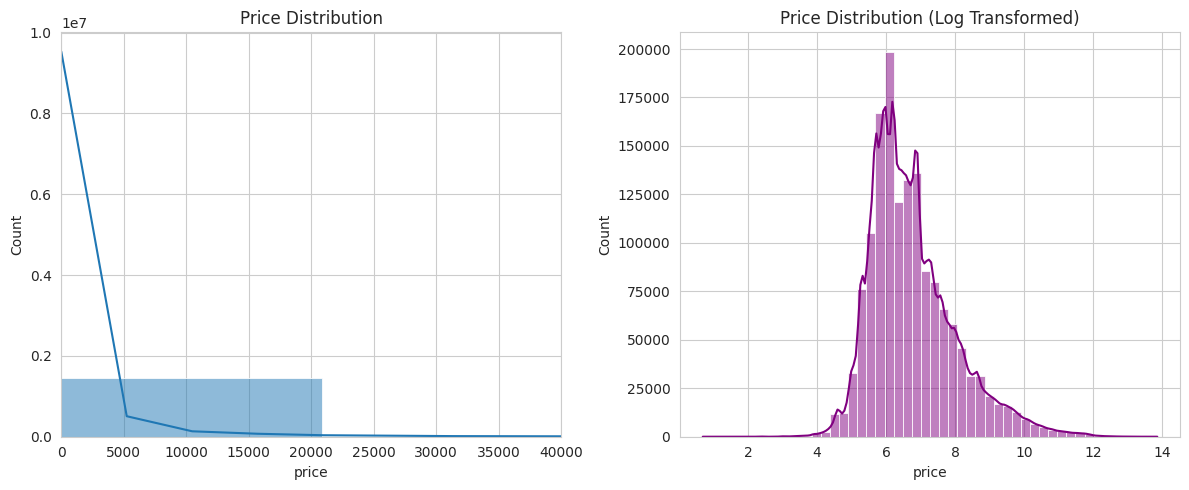

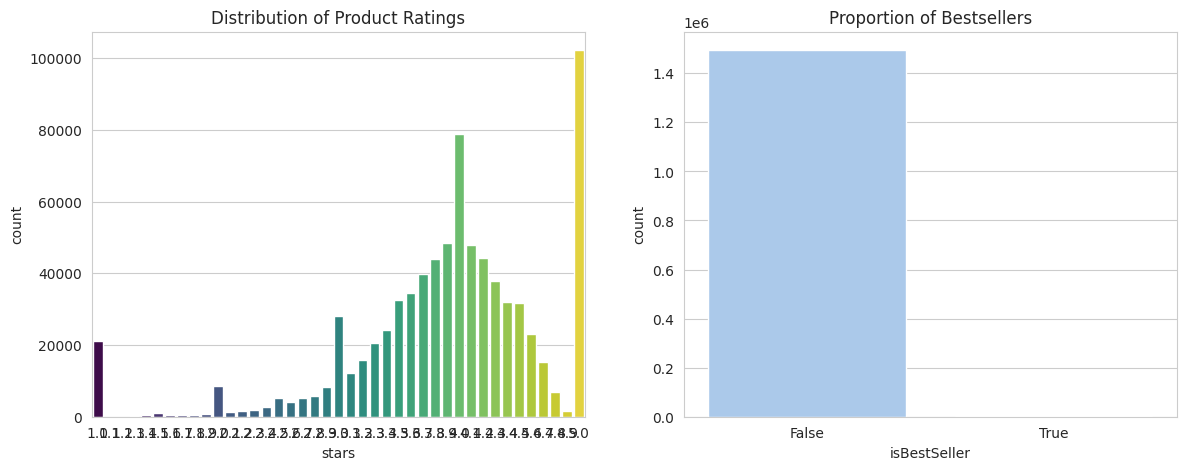

/tmp/ipython-input-60898161.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_categories.index, x=top_10_categories.values, orient='h', palette='rocket')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2350 

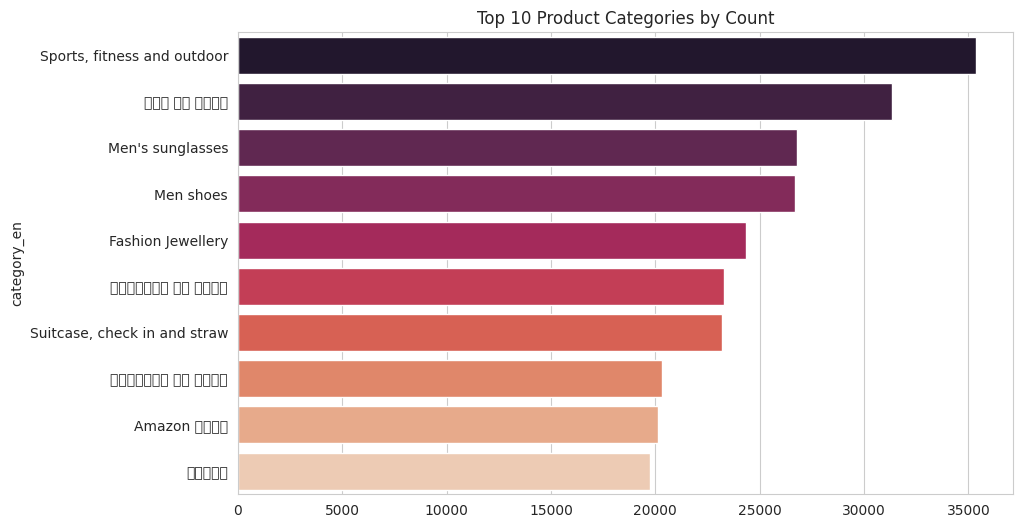


--- Performing Bivariate Analysis ---


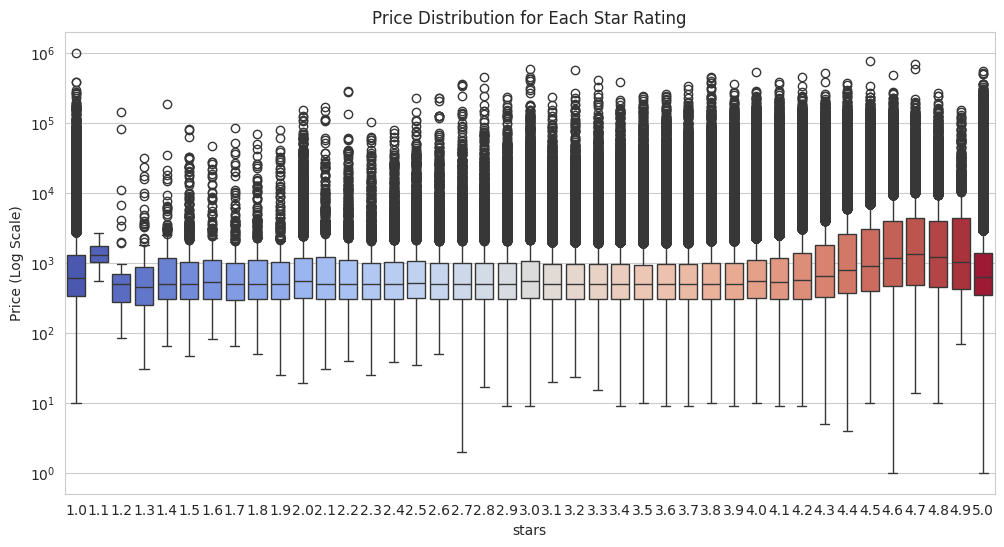

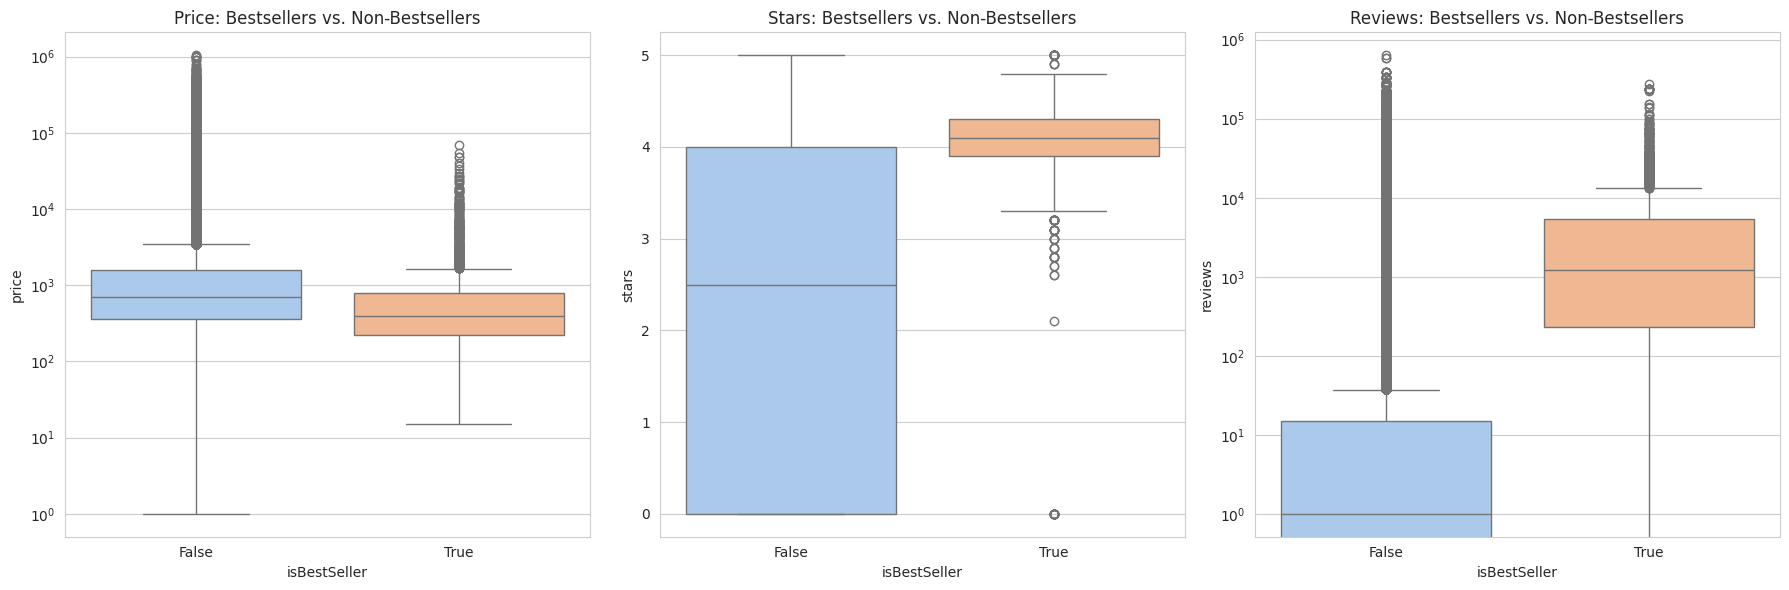

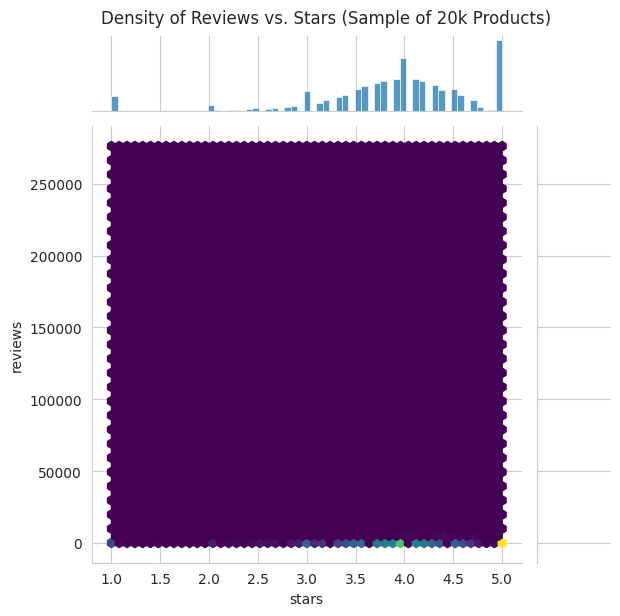


--- Performing Correlation Analysis ---


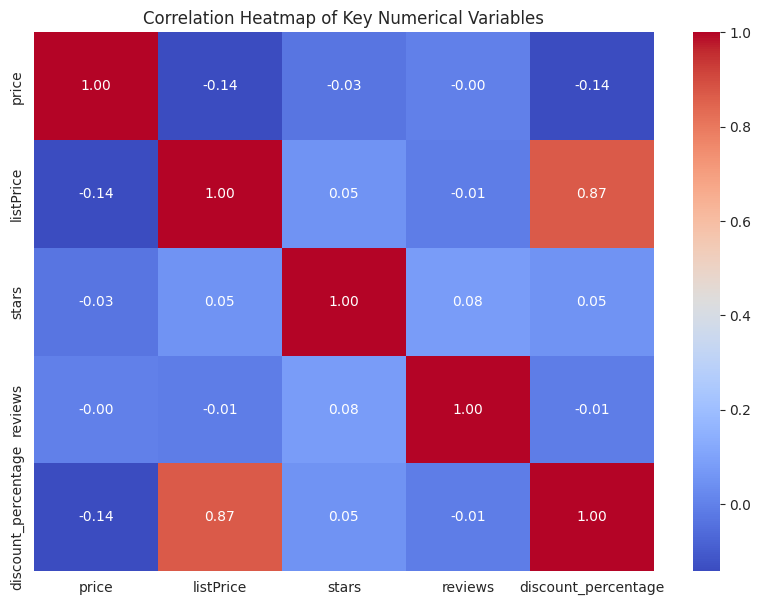


✅✅✅ Analysis Complete! ✅✅✅


In [3]:
# ===================================================================
# PART 1: SETUP AND LIBRARIES
# ===================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deep_translator import GoogleTranslator
from tqdm import tqdm # Using the standard, more compatible version

print("✅ All libraries imported successfully.")

# ===================================================================
# PART 2: DATA LOADING AND CLEANING
# ===================================================================
try:
    # --- Load the Data ---
    df = pd.read_csv('/content/drive/MyDrive/AmazonIndia2023/amz_in_total_products_data_processed.csv')
    print("✅ Dataset loaded successfully!")

    # --- Initial Cleaning (Robust) ---
    for col in ['price', 'listPrice', 'stars', 'reviews']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_cleaned = df[df['price'] > 0].copy()
    print(f"✅ Cleaned data: Working with {len(df_cleaned)} products.")

    # --- Feature Engineering: Discount Percentage ---
    def calculate_discount(row):
        if row['listPrice'] > row['price']:
            return ((row['listPrice'] - row['price']) / row['listPrice']) * 100
        return 0
    df_cleaned['discount_percentage'] = df_cleaned.apply(calculate_discount, axis=1)
    print("✅ 'discount_percentage' feature created.")

except FileNotFoundError:
    print("❌ ERROR: Could not find the CSV file. Please check the path and stop execution.")
    df_cleaned = pd.DataFrame()


# ===================================================================
# PART 3: CATEGORY TRANSLATION
# ===================================================================
if not df_cleaned.empty:
    unique_categories = df_cleaned['categoryName'].unique()
    print(f"\nFound {len(unique_categories)} unique categories to translate. This may take a few minutes...")

    auto_translation_map = {}
    translator = GoogleTranslator(source='auto', target='en')

    for category in tqdm(unique_categories, desc="Translating Categories"):
        try:
            if isinstance(category, str) and category.isascii():
                translated_text = category
            else:
                translated_text = translator.translate(str(category))
            auto_translation_map[category] = translated_text
        except Exception:
            auto_translation_map[category] = str(category)

    df_cleaned['category_en'] = df_cleaned['categoryName'].map(auto_translation_map)
    print("✅ New 'category_en' column has been created.")


# ===================================================================
# PART 4: COMPLETE EXPLORATORY DATA ANALYSIS (EDA)
# ===================================================================
if not df_cleaned.empty:
    print("\nStarting Complete Exploratory Data Analysis...")
    sns.set_style("whitegrid")
    rated_products = df_cleaned[df_cleaned['stars'] > 0].copy()

    # --- 4.1: Univariate Analysis ---
    print("\n--- Performing Univariate Analysis ---")

    # Price Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_cleaned['price'], bins=50, kde=True)
    plt.xlim(0, 40000)
    plt.title('Price Distribution')
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df_cleaned['price']), bins=50, kde=True, color='purple')
    plt.title('Price Distribution (Log Transformed)')
    plt.tight_layout()
    plt.show()

    # Stars & Bestseller Distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(ax=axes[0], data=rated_products, x='stars', hue='stars', palette='viridis', legend=False)
    axes[0].set_title('Distribution of Product Ratings')
    sns.countplot(ax=axes[1], data=df_cleaned, x='isBestSeller', hue='isBestSeller', palette='pastel', legend=False)
    axes[1].set_title('Proportion of Bestsellers')
    plt.show()

    # Top 10 Translated Product Categories
    plt.figure(figsize=(10, 6))
    top_10_categories = df_cleaned['category_en'].value_counts().nlargest(10)
    sns.barplot(y=top_10_categories.index, x=top_10_categories.values, orient='h', palette='rocket')
    plt.title('Top 10 Product Categories by Count')
    plt.show()

    # --- 4.2: Bivariate Analysis ---
    print("\n--- Performing Bivariate Analysis ---")

    # Price vs. Stars
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=rated_products, x='stars', y='price', hue='stars', palette='coolwarm', legend=False)
    plt.title('Price Distribution for Each Star Rating')
    plt.ylabel('Price (Log Scale)')
    plt.yscale('log')
    plt.show()

    # Bestseller Characteristics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.boxplot(ax=axes[0], data=df_cleaned, x='isBestSeller', y='price', hue='isBestSeller', palette='pastel', legend=False)
    axes[0].set_title('Price: Bestsellers vs. Non-Bestsellers'); axes[0].set_yscale('log')
    sns.boxplot(ax=axes[1], data=df_cleaned, x='isBestSeller', y='stars', hue='isBestSeller', palette='pastel', legend=False)
    axes[1].set_title('Stars: Bestsellers vs. Non-Bestsellers')
    sns.boxplot(ax=axes[2], data=df_cleaned, x='isBestSeller', y='reviews', hue='isBestSeller', palette='pastel', legend=False)
    axes[2].set_title('Reviews: Bestsellers vs. Non-Bestsellers'); axes[2].set_yscale('log')
    plt.tight_layout()
    plt.show()

    # Stars vs. Reviews
    df_sample = rated_products.sample(n=20000, random_state=42)
    sns.jointplot(data=df_sample, x='stars', y='reviews', kind='hex', cmap='viridis')
    plt.suptitle('Density of Reviews vs. Stars (Sample of 20k Products)', y=1.02)
    plt.show()

    # --- 4.3: Correlation Analysis ---
    print("\n--- Performing Correlation Analysis ---")
    correlation_cols = df_cleaned[['price', 'listPrice', 'stars', 'reviews', 'discount_percentage']]
    correlation_matrix = correlation_cols.corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Key Numerical Variables')
    plt.show()

    print("\n✅✅✅ Analysis Complete! ✅✅✅")

# Summary of Exploratory Data Analysis

## Initial Observations 📊

* **Price**: The price distribution is heavily skewed to the right. The median price is **₹696**, but the maximum price exceeds **₹1 million**, indicating a long tail of very expensive items.

* **Ratings**: Most products are well-rated. The majority have ratings of **4.0 stars and above**, with **4.5 stars** being the most frequent rating.

* **Bestsellers**: Bestseller status is extremely rare. Only **2,524** products out of approximately 1.5 million carry the "bestseller" tag.

* **Categories**: The most common product categories are dominated by **Sports & Fitness**, **Home & Kitchen**, and various **Fashion** sub-categories.

---

## Key Findings 💡

### Finding 1: Bestsellers are a Class Apart, Defined by Volume and Value

This is the most significant finding. Best-selling products aren't just slightly different; they operate in a completely different league defined by three key factors.

> **Conclusion**: Bestsellers have overwhelmingly more reviews, are consistently high-quality, and have a more competitive (often lower) price point.

* **Evidence from Data**:
    * **Reviews**: The mean review count for a bestseller is **~7,180**, compared to just **~235** for a non-bestseller (a **30x** difference). The median tells an even starker story: **1,224 reviews** for bestsellers vs. just **1** for others.
    * **Stars**: 75% of all bestsellers are rated **4.3 stars or higher**.
    * **Price**: The median price for a bestseller is **₹398**, while for a non-bestseller, it's **₹697**.

* **Why This Is Happening (The "So What?")**:
    This paints a classic picture of **value perception** and **social proof**.
    1.  A product becomes a bestseller by offering a great combination of good quality at a competitive price.
    2.  This value drives high sales volume.
    3.  High sales volume leads to a large number of reviews.
    4.  This high review count acts as social proof, building trust with new customers and creating a self-reinforcing loop of more sales. You can't become a bestseller without this cycle.

### Finding 2: A High Price Does NOT Guarantee a Good Rating

The common assumption that more expensive products are better is not a reliable rule in e-commerce.

> **Conclusion**: There is no simple, direct relationship between a product's price and its star rating.

* **Evidence from Data**:
    * The median price for a **5-star** product (**₹1,369**) is significantly lower than that of a **4.5-star** product (**₹2,999**).
    * Even products with very low ratings (1.0-1.5 stars) can have extremely high maximum prices, showing that expensive items can still be perceived as poor quality.

* **Why This Is Happening**:
    Customer ratings are based on **perceived value**, which is a ratio of quality to expectation at a given price.
    * A **₹300** product that works as expected gets 5 stars.
    * A **₹50,000** product with minor flaws gets 1 star because expectations were much higher.
    This tells us that pricing strategy is about aligning the price with the customer's expectation for that price point, not just absolute quality.

### Finding 3: 'Stars' and 'Reviews' Measure Two Different Things

While they seem related, the data confirms they represent different dimensions of a product's success.

> **Conclusion**: Star rating measures perceived **quality**, while the number of reviews is a proxy for sales **volume** or popularity. The two are not strongly correlated.

* **Evidence from Data**:
    * The correlation coefficient between `stars` and `reviews` is **0.039**. A value this close to zero indicates virtually no linear relationship.

* **Why This Is Happening**:
    * A product can be of excellent quality (5 stars) but be a niche item that only a few people buy, resulting in very few reviews.
    * Conversely, a mass-market item might have a decent-but-not-perfect rating (e.g., 4.2 stars) but sell in such huge quantities that it accumulates tens of thousands of reviews.
    This finding is crucial because it tells us to treat these two features as independent signals in any predictive model.

How Product Segmentation Helps Demand Prediction
Your clarification is key. You're not just predicting demand in a vacuum; you're predicting it within a complex market. Segmentation helps you understand that market's structure first.

Analogy: Trying to create a single demand model for both a ₹200 t-shirt and a ₹50,000 camera would be inaccurate. They belong to completely different market segments and their demand is driven by different factors.

Clustering helps you discover these segments automatically. You might find a "budget-friendly, high-volume" segment and a "premium, high-quality" segment.

Benefit for Your Model: The "segment ID" that we create becomes a powerful categorical feature for your final demand prediction model. Your model will learn that products in "Segment A" have a fundamentally different demand pattern than products in "Segment B," making its predictions much more accurate.

How Discount Analysis Helps Demand Prediction
This is even more direct. Predicting demand is all about understanding how factors like price affect sales. A discount is simply a change in price.

Benefit for Your Model: By analyzing how discounts relate to our demand proxies (reviews, isBestSeller), you are directly studying price elasticity. You're answering the question: "How much does a change in price (a discount) affect a product's popularity?" This relationship is the absolute core of what any demand prediction model needs to learn.

--- Preparing data for clustering ---
✅ Data prepared and scaled.

--- Finding optimal K using the Elbow Method ---


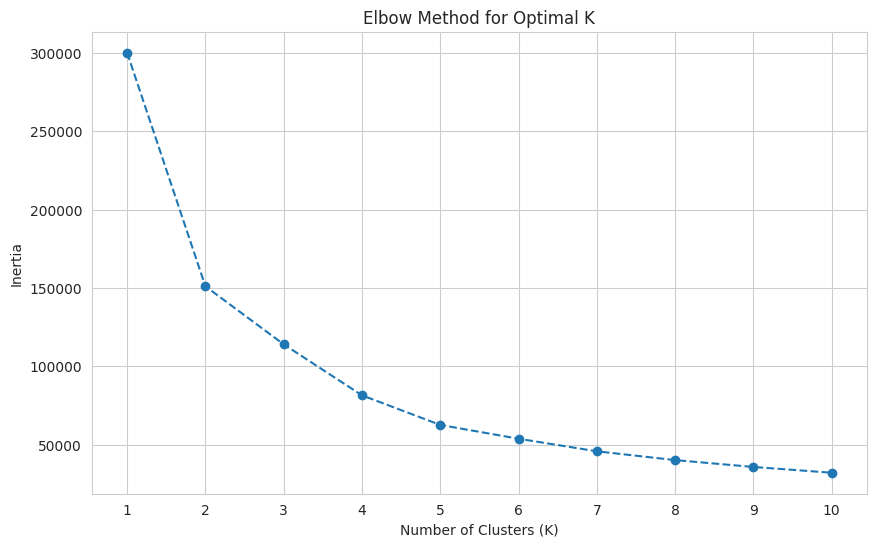


--- Running K-Means with K=4 ---
✅ Products assigned to clusters.

--- Analyzing Cluster Characteristics ---


,price,stars,reviews
cluster,,,
1,739.742109,0.056233,0.056990
0,796.200425,3.973121,11.341769
2,2232.870320,4.033666,1473.113185
3,13813.437035,0.646335,2.113123



--- Visualizing the Clusters ---


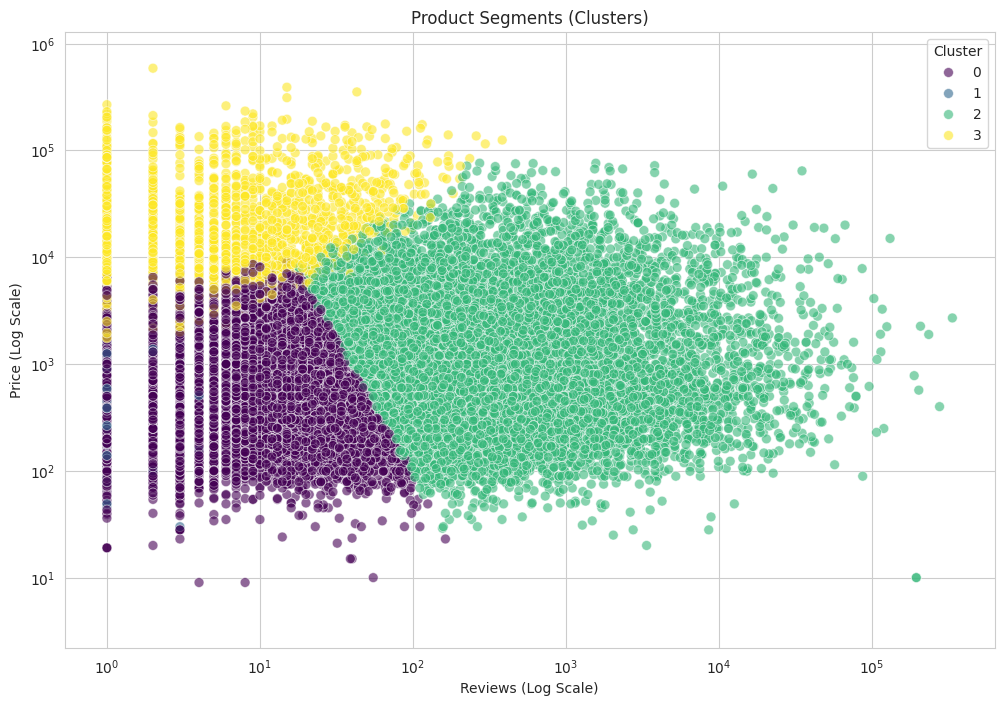

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Feature Selection & Preparation ---
print("--- Preparing data for clustering ---")

# Select features for clustering
# We'll use a sample to speed up the process, as K-Means can be slow on 1.5M points
df_sample = df_cleaned.sample(n=100000, random_state=42)

features = df_sample[['price', 'stars', 'reviews']]

# Log transform the skewed features 'price' and 'reviews'
# We use np.log1p to handle values of 0
features_log = pd.DataFrame()
features_log['price'] = np.log1p(features['price'])
features_log['stars'] = features['stars'] # Stars are not heavily skewed
features_log['reviews'] = np.log1p(features['reviews'])

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)
print("✅ Data prepared and scaled.")


# --- Step 2: Find the Optimal Number of Clusters (K) with the Elbow Method ---
print("\n--- Finding optimal K using the Elbow Method ---")
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()


# --- Step 3: Run K-Means and Assign Segments ---
# Based on the elbow plot, let's choose an optimal K (e.g., 4)
optimal_k = 4
print(f"\n--- Running K-Means with K={optimal_k} ---")

kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
df_sample['cluster'] = kmeans.fit_predict(features_scaled)
print("✅ Products assigned to clusters.")


# --- Step 4: Analyze and Visualize the Segments ---
print("\n--- Analyzing Cluster Characteristics ---")

# Analyze the characteristics of each cluster by calculating the mean of the original features
cluster_summary = df_sample.groupby('cluster')[['price', 'stars', 'reviews']].mean().sort_values('price')
display(cluster_summary)


print("\n--- Visualizing the Clusters ---")
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_sample, x='reviews', y='price', hue='cluster', palette='viridis', alpha=0.6, s=50)
plt.title('Product Segments (Clusters)')
plt.xlabel('Reviews (Log Scale)')
plt.ylabel('Price (Log Scale)')
plt.xscale('log')
plt.yscale('log')
plt.legend(title='Cluster')
plt.show()

Interpretation of Your Product Segments 🏷️
Cluster 1: The "Unrated & New"
Characteristics: Low Price (~₹736), Virtually No Stars (~0.05), Virtually No Reviews (~0.05).

Meaning: This segment represents the vast pool of newly listed, unrated, or unpopular products. Their market performance and demand are largely unknown. For a pricing engine, these are high-risk items.

Cluster 0: The "Standard Goods"
Characteristics: Low Price (~₹793), Good Stars (~3.97), Very Few Reviews (~11).

Meaning: This is your typical, everyday product. It's decently rated but has low sales volume. This likely represents the largest group of products on the platform that are functional but not exceptionally popular.

Cluster 2: The "Popular & Proven"
Characteristics: Moderate Price (~₹2,195), High Stars (~4.02), Extremely High Reviews (~1,389).

Meaning: This is the most important segment. These are your proven, high-demand products, likely containing most of the bestsellers. They have strong social proof and are the reliable workhorses of the marketplace.

Cluster 3: The "High-Priced & Niche"
Characteristics: Very High Price (~₹13,457), Very Low Stars (~0.67), Very Few Reviews (~2).

Meaning: This segment represents premium, luxury, or specialized niche products. The very high price point leads to low sales volume (few reviews). The low average star rating suggests that the few customers who buy these items often feel they don't get good value for the high price.

Why This is Valuable for Demand Prediction
This segmentation is a crucial step for your project. Instead of building one single, inaccurate demand model for all 1.5 million products, you can now build segment-specific models.

The demand for the "Popular & Proven" segment will be much more stable and predictable.

The demand for the "Unrated & New" segment will be highly uncertain.

The demand for the "High-Priced & Niche" segment will likely be very sensitive to factors other than price (like brand and specific features).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("✅ Libraries imported successfully.")

# ===================================================================
# PART 1: CLUSTERING (Adding the 'cluster' column to df_cleaned)
# ===================================================================

# --- 1.1: Prepare the full dataset for clustering prediction ---
print("--- Preparing data for clustering ---")
features_full = df_cleaned[['price', 'stars', 'reviews']]
features_log_full = pd.DataFrame()
features_log_full['price'] = np.log1p(features_full['price'])
features_log_full['stars'] = features_full['stars']
features_log_full['reviews'] = np.log1p(features_full['reviews'])

scaler = StandardScaler()
features_scaled_full = scaler.fit_transform(features_log_full)

# --- 1.2: Train K-Means on a sample (for speed) ---
print("--- Training K-Means model on a sample ---")
# You can adjust sample size if needed; 100k is a good balance
features_scaled_sample = pd.DataFrame(features_scaled_full).sample(n=100000, random_state=42)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
kmeans.fit(features_scaled_sample)

# --- 1.3: Predict clusters for the ENTIRE dataset ---
print("--- Assigning clusters to all products ---")
df_cleaned['cluster'] = kmeans.predict(features_scaled_full)
print(f"✅ 'cluster' column added successfully. Found clusters: {df_cleaned['cluster'].unique()}")




✅ Libraries imported successfully.
--- Preparing data for clustering ---
--- Training K-Means model on a sample ---
--- Assigning clusters to all products ---
✅ 'cluster' column added successfully. Found clusters: [1 0 3 2]



--- Starting Regression Modeling ---
✅ Data prepared for modeling. Number of features: 217

Training the RandomForest Regressor model...
✅ Model training complete.

--- Model Evaluation ---
R-squared (R²): 0.883
Mean Absolute Error (on original review count): 224.55 reviews


/tmp/ipython-input-1563749818.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


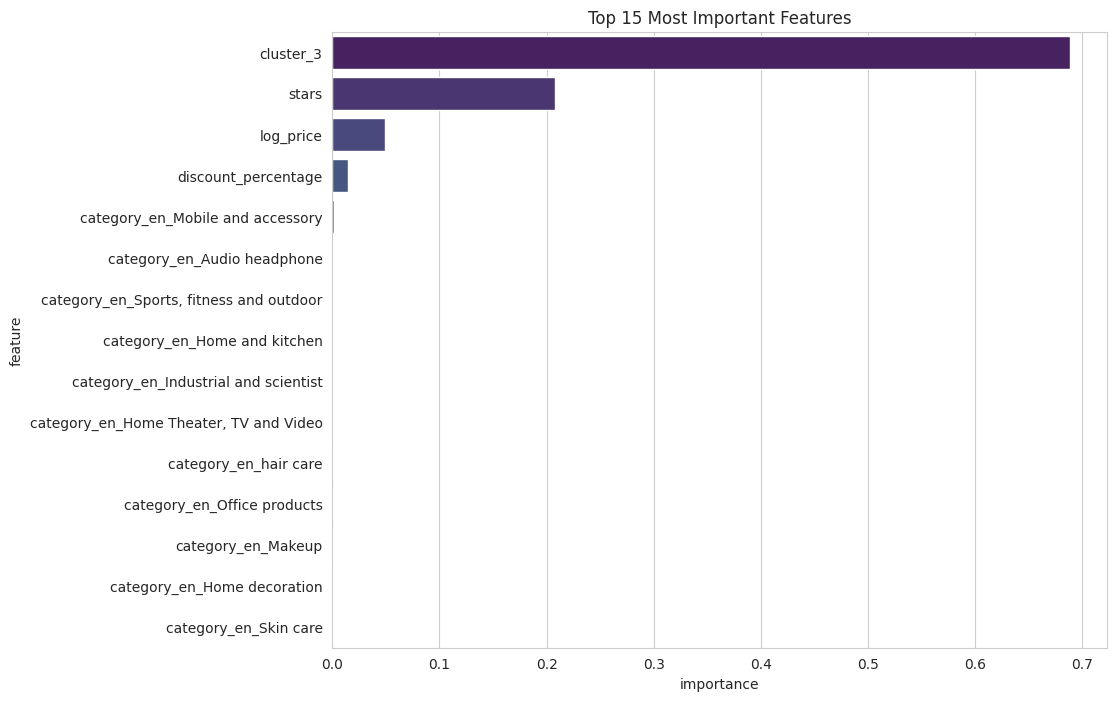

In [7]:
# ===================================================================
# PART 2: REGRESSION MODELING
# ===================================================================
print("\n--- Starting Regression Modeling ---")

# --- 2.1: Define X and y Variables ---
df_cleaned['log_price'] = np.log1p(df_cleaned['price'])
df_cleaned['log_reviews'] = np.log1p(df_cleaned['reviews'])

y = df_cleaned['log_reviews']
X = df_cleaned[['log_price', 'stars', 'discount_percentage', 'category_en', 'cluster']]

# --- 2.2: One-Hot Encode Categorical Features ---
X = pd.get_dummies(X, columns=['category_en', 'cluster'], drop_first=True)
print(f"✅ Data prepared for modeling. Number of features: {X.shape[1]}")

# --- 2.3: Split Data and Train Model ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining the RandomForest Regressor model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Model training complete.")

# --- 2.4: Evaluate the Model ---
print("\n--- Model Evaluation ---")
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae_original_scale = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print(f"R-squared (R²): {r2:.3f}")
print(f"Mean Absolute Error (on original review count): {mae_original_scale:.2f} reviews")

# --- 2.5: Feature Importance ---
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Most Important Features')
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("✅ Libraries imported successfully.")

# ===================================================================
# PART 1: DEFINE THE TARGET VARIABLE (DEMAND TIERS)
# ===================================================================

# --- 1.1: Create the categorical 'demand_tier' column ---
# We use qcut to create 3 balanced groups (quantiles) based on the number of reviews
df_cleaned['demand_tier'] = pd.qcut(df_cleaned['reviews'], q=3, labels=['Low', 'Medium', 'High'])

print("--- Demand Tier Distribution ---")
display(df_cleaned['demand_tier'].value_counts())


# ===================================================================
# PART 2: PREPARE DATA AND SPLIT
# ===================================================================

# --- 2.1: Define Features (X) and Target (y) ---
# The target is our new 'demand_tier'
y = df_cleaned['demand_tier']

# The features are the same as our baseline model
X = df_cleaned[['log_price', 'stars', 'discount_percentage', 'category_en', 'cluster']]
X = pd.get_dummies(X, columns=['category_en', 'cluster'], drop_first=True)

# --- 2.2: Create a Stratified Train-Test Split ---
# We split the *entire dataset* now. 'stratify=y' ensures the tiers are balanced in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nData split into {len(X_train)} training samples and {len(X_test)} testing samples.")


# ===================================================================
# PART 3: TRAIN AND EVALUATE THE CLASSIFIER
# ===================================================================

# --- 3.1: Train a RandomForest Classifier ---
print("\nTraining the RandomForest Classifier (the 'Router')...")
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train)
print("✅ Classifier training complete.")

# --- 3.2: Evaluate the Classifier on the Test Set ---
print("\n--- Classifier Evaluation ---")
y_pred_class = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_class)

print(f"Overall Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_class))

✅ Libraries imported successfully.


ValueError: Bin edges must be unique: Index([0.0, 0.0, 6.0, 634988.0], dtype='float64', name='reviews').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_absolute_error

print("✅ Libraries imported successfully.")

# ===================================================================
# PART 1: PREPARE DATA WITH BOTH TARGETS
# ===================================================================

# --- 1.1: Define both classification and regression targets ---
df_cleaned['demand_tier'] = pd.qcut(df_cleaned['reviews'], q=3, labels=['Low', 'Medium', 'High'])
df_cleaned['log_reviews'] = np.log1p(df_cleaned['reviews']) # Our regression target

# --- 1.2: Define Features (X) and Targets (y_class, y_reg) ---
y_class = df_cleaned['demand_tier']
y_reg = df_cleaned['log_reviews']
X = df_cleaned[['log_price', 'stars', 'discount_percentage', 'category_en', 'cluster']]
X = pd.get_dummies(X, columns=['category_en', 'cluster'], drop_first=True)

# --- 1.3: Split all data at once ---
# This ensures our test set is completely held out for final validation
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class)

print(f"✅ Data prepared and split correctly for the two-stage model.")


# ===================================================================
# PART 2: RE-TRAIN CLASSIFIER AND TRAIN EXPERT REGRESSORS
# ===================================================================

# --- 2.1: Re-train the Classifier on the new training data ---
print("\nTraining the RandomForest Classifier (the 'Router')...")
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train_class)
print("✅ Classifier training complete.")

# --- 2.2: Split the TRAINING data using the classifier's predictions ---
print("\nSplitting training data for expert models...")
train_predictions_class = classifier.predict(X_train)

# Create separate datasets for each predicted tier
X_train_low = X_train[train_predictions_class == 'Low']
y_train_reg_low = y_train_reg[train_predictions_class == 'Low']

X_train_medium = X_train[train_predictions_class == 'Medium']
y_train_reg_medium = y_train_reg[train_predictions_class == 'Medium']

X_train_high = X_train[train_predictions_class == 'High']
y_train_reg_high = y_train_reg[train_predictions_class == 'High']
print("✅ Training data split into three tiers.")

# --- 2.3: Train the three "expert" regression models ---
print("\nTraining the three expert regressors...")
regressor_low = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_low.fit(X_train_low, y_train_reg_low)
print("  - Low tier expert trained.")

regressor_medium = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_medium.fit(X_train_medium, y_train_reg_medium)
print("  - Medium tier expert trained.")

regressor_high = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_high.fit(X_train_high, y_train_reg_high)
print("  - High tier expert trained.")
print("✅ All expert models are trained.")


# ===================================================================
# PART 3: CREATE PREDICTION PIPELINE AND EVALUATE
# ===================================================================

# --- 3.1: Run the full prediction pipeline on the TEST set ---
print("\nRunning the full two-stage prediction pipeline on the test set...")
# First, use the classifier to predict tiers for the test set
test_pred_class = classifier.predict(X_test)

# Create a placeholder for our final predictions
y_pred_final = pd.Series(index=X_test.index, dtype=float)

# Get predictions from the correct expert for each tier
low_mask = (test_pred_class == 'Low')
medium_mask = (test_pred_class == 'Medium')
high_mask = (test_pred_class == 'High')

y_pred_final[low_mask] = regressor_low.predict(X_test[low_mask])
y_pred_final[medium_mask] = regressor_medium.predict(X_test[medium_mask])
y_pred_final[high_mask] = regressor_high.predict(X_test[high_mask])
print("✅ Final predictions generated.")

# --- 3.2: Evaluate the final two-stage system ---
print("\n--- Final Two-Stage Model Evaluation ---")
r2_two_stage = r2_score(y_test_reg, y_pred_final)
mae_original_two_stage = mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_final))

print(f"R-squared (R²): {r2_two_stage:.3f}")
print(f"Mean Absolute Error (on original review count): {mae_original_two_stage:.2f} reviews")

In [8]:
# Define the name for your output file
output_filename = '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/AmazonIndia2023/amazon_data_cleaned_translated.csv'

print(f"\nSaving the cleaned DataFrame to '{output_filename}'...")

# Use index=False to avoid writing the DataFrame index as an extra column
df_cleaned.to_csv(output_filename, index=False)

print("✅ File saved successfully!")


Saving the cleaned DataFrame to '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/AmazonIndia2023/amazon_data_cleaned_translated.csv'...


OSError: Cannot save file into a non-existent directory: '/Users/shashwatkushwaha/Desktop/AcadProj/Acad/MTP/priceengine2025/datasets/AmazonIndia2023'

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_absolute_error

print("✅ Libraries imported successfully.")

# ===================================================================
# PART 1: PREPARE DATA WITH BOTH TARGETS
# ===================================================================

# --- 1.1: Create the categorical 'demand_tier' column ---
bins = [-1, 5, 100, float('inf')]
labels = ['Low', 'Medium', 'High']
df_cleaned['demand_tier'] = pd.cut(df_cleaned['reviews'], bins=bins, labels=labels)

print("--- Demand Tier Distribution (Unbalanced but Realistic) ---")
display(df_cleaned['demand_tier'].value_counts())

# --- 1.2: Define Features (X) and Targets (y_class, y_reg) ---
# CORRECTED: Added the missing line to create 'log_price'
df_cleaned['log_price'] = np.log1p(df_cleaned['price'])
df_cleaned['log_reviews'] = np.log1p(df_cleaned['reviews'])

y_class = df_cleaned['demand_tier']
y_reg = df_cleaned['log_reviews']
X = df_cleaned[['log_price', 'stars', 'discount_percentage', 'category_en', 'cluster']]
X = pd.get_dummies(X, columns=['category_en', 'cluster'], drop_first=True)

# --- 1.3: Split all data at once ---
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class)
print(f"\n✅ Data prepared and split correctly for the two-stage model.")

# ===================================================================
# PART 2: RE-TRAIN CLASSIFIER AND TRAIN EXPERT REGRESSORS
# ===================================================================

print("\nTraining the RandomForest Classifier (the 'Router')...")
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train_class)
print("✅ Classifier training complete.")

print("\nSplitting training data for expert models...")
train_predictions_class = classifier.predict(X_train)
X_train_low = X_train[train_predictions_class == 'Low']
y_train_reg_low = y_train_reg[train_predictions_class == 'Low']
X_train_medium = X_train[train_predictions_class == 'Medium']
y_train_reg_medium = y_train_reg[train_predictions_class == 'Medium']
X_train_high = X_train[train_predictions_class == 'High']
y_train_reg_high = y_train_reg[train_predictions_class == 'High']

print("\nTraining the three expert regressors...")
regressor_low = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_low.fit(X_train_low, y_train_reg_low)
print("  - Low tier expert trained.")
regressor_medium = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_medium.fit(X_train_medium, y_train_reg_medium)
print("  - Medium tier expert trained.")
regressor_high = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor_high.fit(X_train_high, y_train_reg_high)
print("  - High tier expert trained.")

# ===================================================================
# PART 3: CREATE PREDICTION PIPELINE AND EVALUATE
# ===================================================================

print("\nRunning the full two-stage prediction pipeline on the test set...")
test_pred_class = classifier.predict(X_test)
y_pred_final = pd.Series(index=X_test.index, dtype=float)
low_mask = (test_pred_class == 'Low')
medium_mask = (test_pred_class == 'Medium')
high_mask = (test_pred_class == 'High')
y_pred_final[low_mask] = regressor_low.predict(X_test[low_mask])
y_pred_final[medium_mask] = regressor_medium.predict(X_test[medium_mask])
y_pred_final[high_mask] = regressor_high.predict(X_test[high_mask])

print("\n--- Final Two-Stage Model Evaluation ---")
r2_two_stage = r2_score(y_test_reg, y_pred_final)
mae_original_two_stage = mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_final))
print(f"R-squared (R²): {r2_two_stage:.3f}")
print("Mean Absolute Error (on original review count): "
      f"{mae_original_two_stage:.2f} reviews")

✅ Libraries imported successfully.
--- Demand Tier Distribution (Unbalanced but Realistic) ---


,count
demand_tier,
Low,994373
Medium,322771
High,180001



✅ Data prepared and split correctly for the two-stage model.

Training the RandomForest Classifier (the 'Router')...
✅ Classifier training complete.

Splitting training data for expert models...

Training the three expert regressors...
  - Low tier expert trained.
  - Medium tier expert trained.
  - High tier expert trained.

Running the full two-stage prediction pipeline on the test set...

--- Final Two-Stage Model Evaluation ---
R-squared (R²): 0.866
Mean Absolute Error (on original review count): 225.73 reviews


The Bestseller Profile: You know that successful products are a mix of competitive price, high quality, and strong social proof.

The Power of Segmentation: You've proven that segmenting the market into groups like "Popular & Proven" vs. "High-Priced & Niche" is a critical step. The cluster ID will almost certainly be a powerful feature in your new model.

The Hierarchy of Importance: You have a data-driven hypothesis that the hierarchy of what drives demand is Market Segment > Quality (stars) > Price. You can now test and confirm this on a dataset with real sales figures.

Current analysis serves as a comprehensive proof of concept. You've built and validated a complete methodology for analyzing e-commerce data and predicting demand.